In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

In [41]:
df = pd.read_csv("./retail.csv")
df

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied
...,...,...,...,...,...,...,...,...,...,...,...
345,446,Male,32,Miami,Silver,660.30,10,3.8,True,42,Unsatisfied
346,447,Female,36,Houston,Bronze,470.50,8,3.0,False,27,Neutral
347,448,Female,30,New York,Gold,1190.80,16,4.5,True,28,Satisfied
348,449,Male,34,Los Angeles,Silver,780.20,11,4.2,False,21,Neutral


# 1. EDA & Data Preparation

In [42]:
PALETTE = ["#4C6EF5", "#F76707", "#2F9E44", "#E03131", "#7048E8", "#0CA678"]

In [43]:
print(df.head())
print(f"\nShape: {df.shape}")
print(df.dtypes)

   Customer ID  Gender  Age           City Membership Type  Total Spend  \
0          101  Female   29       New York            Gold      1120.20   
1          102    Male   34    Los Angeles          Silver       780.50   
2          103  Female   43        Chicago          Bronze       510.75   
3          104    Male   30  San Francisco            Gold      1480.30   
4          105    Male   27          Miami          Silver       720.40   

   Items Purchased  Average Rating  Discount Applied  \
0               14             4.6              True   
1               11             4.1             False   
2                9             3.4              True   
3               19             4.7             False   
4               13             4.0              True   

   Days Since Last Purchase Satisfaction Level  
0                        25          Satisfied  
1                        18            Neutral  
2                        42        Unsatisfied  
3               

In [44]:

fig = plt.figure(figsize=(8,6))
gs = gridspec.GridSpec(1, 1)

<Figure size 800x600 with 0 Axes>

## Missing Values

In [45]:
print("\n[Missing Values per Column]")
mv = df.isnull().sum()

print(mv[mv>0] if mv.sum() > 0 else "Tidak ada missing values")
print(mv)



[Missing Values per Column]
Satisfaction Level    2
dtype: int64
Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64


In [46]:
df = df.dropna(subset=["Satisfaction Level"])

print(df["Satisfaction Level"].unique())
print(df.isnull().sum())

['Satisfied' 'Neutral' 'Unsatisfied']
Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          0
dtype: int64


In [47]:
spend = df["Total Spend"].copy()

z_scores = np.abs(stats.zscore(spend))
z_outliers = df[z_scores > 3].copy()
z_outliers["z_score"] = z_scores[z_scores > 3]

In [48]:
Q1, Q3 = spend.quantile(0.25), spend.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_outliers = df[(spend < lower) | (spend>upper)].copy()

print(f"\nZ_Score (|z| > 3) -> {len(z_outliers)} outliers")
print(f"IQR ( < {lower:.0f} | >{upper: .0f}) -> {len(iqr_outliers)} outliers")


Z_Score (|z| > 3) -> 0 outliers
IQR ( < -477 | > 2143) -> 0 outliers


In [49]:
iqr_outliers["outliers_type"] = np.where(iqr_outliers["Total Spend"] < 0, "Data Error", "Potential VIP")

vip_customers = iqr_outliers[iqr_outliers["outliers_type"] == "Potential VIP"]
error_customers = iqr_outliers[iqr_outliers["outliers_type"] == "Data Error"]

print(f"Potential VIP: {len(vip_customers)} pelanggan (Total Spend > {upper: .0f})")
print(f"\nData Error: {len(error_customers)} pelanggan (Total Spend > {lower: .0f})")

print(vip_customers[["Customer ID", "Total Spend"]].head())
print(error_customers[["Customer ID", "Total Spend"]].head())

Potential VIP: 0 pelanggan (Total Spend >  2143)

Data Error: 0 pelanggan (Total Spend > -477)
Empty DataFrame
Columns: [Customer ID, Total Spend]
Index: []
Empty DataFrame
Columns: [Customer ID, Total Spend]
Index: []


Dari Z-Score dan IQR menunjukkan bahwa outlier tidak ada sama sekali. Oleh karena itu, tidak ada vip_customers atau data error

## Future Engineering

In [50]:
df_clean = df[df["Total Spend"] >= 0].copy()

df_clean = df_clean.copy()
df_clean["Purchase_Intensity"] = (
    df_clean["Items Purchased"] / df_clean["Days Since Last Purchase"].replace(0, 1)
)

print("\n[Statistik Purchase Intensity]")
print(df_clean["Purchase_Intensity"].describe().round(4))
print(df_clean[["Customer ID", "Items Purchased", "Days Since Last Purchase", "Purchase_Intensity"]].head())


[Statistik Purchase Intensity]
count    348.0000
mean       0.6843
std        0.5694
min        0.1875
25%        0.2553
50%        0.4444
75%        0.8421
max        2.3333
Name: Purchase_Intensity, dtype: float64
   Customer ID  Items Purchased  Days Since Last Purchase  Purchase_Intensity
0          101               14                        25            0.560000
1          102               11                        18            0.611111
2          103                9                        42            0.214286
3          104               19                        12            1.583333
4          105               13                        55            0.236364


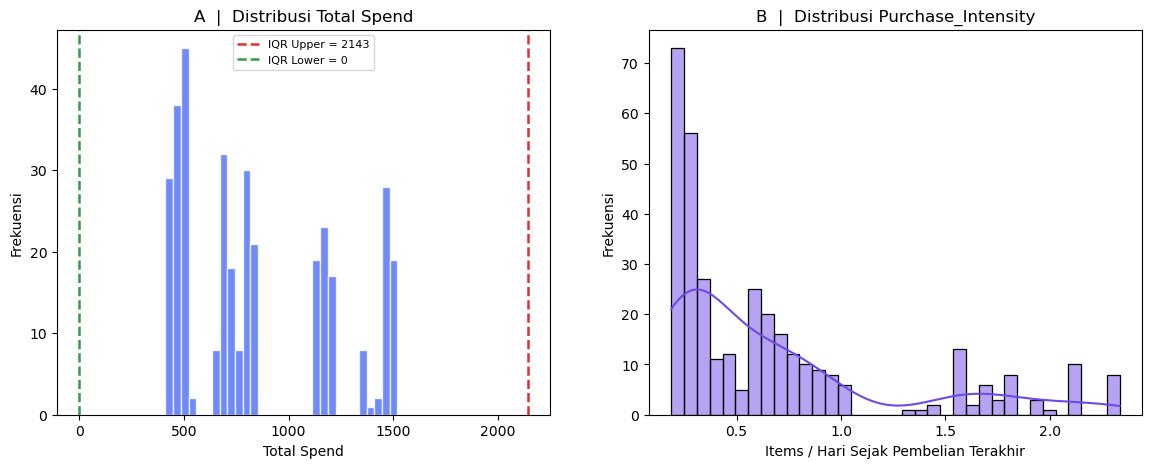

In [51]:
plt.figure(figsize=(14, 5))

plt.subplot(1,2,1)
plt.title("A  |  Distribusi Total Spend")
plt.hist(df_clean["Total Spend"], bins=30,
          color=PALETTE[0],
          alpha=0.8,
          edgecolor="white")

plt.axvline(upper, color=PALETTE[3], ls="--", lw=1.8,
             label=f"IQR Upper = {upper:.0f}")
plt.axvline(lower if lower > 0 else 0, color=PALETTE[2], ls="--", lw=1.8,
             label=f"IQR Lower = {max(lower,0):.0f}")
plt.xlabel("Total Spend")
plt.ylabel("Frekuensi")
plt.legend(fontsize=8)

plt.subplot(1,2,2)
plt.title("B  |  Distribusi Purchase_Intensity")
sns.histplot(df_clean["Purchase_Intensity"], bins=35,
             color=PALETTE[4], kde=True)
plt.xlabel("Items / Hari Sejak Pembelian Terakhir")
plt.ylabel("Frekuensi")

plt.show()

## Standaritazion

In [52]:
features = [
    "Age", "Total Spend", "Items Purchased", "Average Rating", "Days Since Last Purchase"
]

features_ext= features + ["Purchase_Intensity"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_clean[features_ext])
X_df = pd.DataFrame(X_scaled, columns=features_ext)

print("\n[Sebelum Standarisasi - Statistik Dasar]")
print(df_clean[features].describe().round(2))
print("\n[Sesudah Standarisasi - Mean & Std]")
print(X_df.describe().loc[["mean", "std"]].round(3))


[Sebelum Standarisasi - Statistik Dasar]
          Age  Total Spend  Items Purchased  Average Rating  \
count  348.00       348.00           348.00          348.00   
mean    33.58       847.79            12.63            4.02   
std      4.88       361.69             4.15            0.58   
min     26.00       410.80             7.00            3.00   
25%     30.00       505.75             9.00            3.50   
50%     32.00       780.20            12.00            4.10   
75%     37.00      1160.60            15.00            4.50   
max     43.00      1520.10            21.00            4.90   

       Days Since Last Purchase  
count                    348.00  
mean                      26.61  
std                       13.47  
min                        9.00  
25%                       15.00  
50%                       23.00  
75%                       38.00  
max                       63.00  

[Sesudah Standarisasi - Mean & Std]
        Age  Total Spend  Items Purchased  Aver

# 2. Unsupervised Learning

## Elbow Method & K-Means

In [53]:
inertia = []
silhouette_kms = []
K_range = range(2, 11)

for k in K_range :
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette_kms.append(silhouette_score(X_scaled, km.labels_))
    print(f"  K={k:2d}  |  Inertia={km.inertia_:8,.1f}  "
          f"|  Silhouette={silhouette_kms[-1]:.4f}")

  K= 2  |  Inertia=   968.9  |  Silhouette=0.4563
  K= 3  |  Inertia=   562.9  |  Silhouette=0.4941
  K= 4  |  Inertia=   323.3  |  Silhouette=0.5835
  K= 5  |  Inertia=   226.9  |  Silhouette=0.6117
  K= 6  |  Inertia=   132.9  |  Silhouette=0.6640
  K= 7  |  Inertia=    81.8  |  Silhouette=0.7054
  K= 8  |  Inertia=    65.4  |  Silhouette=0.6861
  K= 9  |  Inertia=    58.3  |  Silhouette=0.6480
  K=10  |  Inertia=    50.7  |  Silhouette=0.6382


In [54]:
deltas = np.diff(inertia)
second_diff = np.diff(deltas)
optimal_k = K_range.start + np.argmax(second_diff) + 1

best_sil_k = list(K_range)[np.argmax(silhouette_kms)]
print(f"\n Elbow heuristik (second-derivative): K = {optimal_k}")
print(f"\n Silhouette tertinggi: K = {best_sil_k}"
      f"(skor={max(silhouette_kms):.4f})")

chosen_k = best_sil_k
print(f"\n K yang dipilih = {chosen_k} berdasarkan silhouette tertinggi")


 Elbow heuristik (second-derivative): K = 3

 Silhouette tertinggi: K = 7(skor=0.7054)

 K yang dipilih = 7 berdasarkan silhouette tertinggi


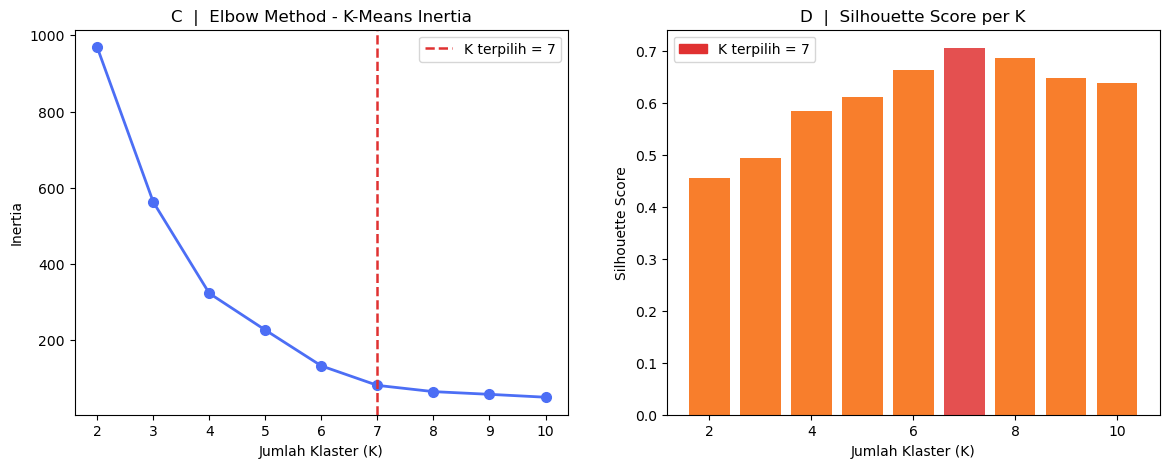

In [55]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.title("C  |  Elbow Method - K-Means Inertia")
plt.plot(list(K_range), inertia, "o-", color=PALETTE[0], lw=2, ms=7)
plt.axvline(chosen_k, color=PALETTE[3], ls="--", lw=1.8,
             label=f"K terpilih = {chosen_k}")
plt.xlabel("Jumlah Klaster (K)")
plt.ylabel("Inertia")
plt.legend()

plt.subplot(1,2,2)
plt.title("D  |  Silhouette Score per K")
colors_bar = [PALETTE[3] if k == chosen_k else PALETTE[1]
              for k in K_range]
plt.bar(list(K_range), silhouette_kms, color=colors_bar, alpha=0.85)
plt.xlabel("Jumlah Klaster (K)")
plt.ylabel("Silhouette Score")
plt.legend(handles=[plt.Rectangle((0,0),1,1, color=PALETTE[3])],
            labels=[f"K terpilih = {chosen_k}"])
plt.show()

In [56]:
km_final = KMeans(n_clusters=chosen_k, init="k-means++", n_init=10, random_state=42)
km_final.fit(X_scaled)
df_clean["KMeans Cluster"] = km_final.labels_

print("\n[ Distribusi Pelanggan per Klaster ]")
print(df_clean["KMeans Cluster"].value_counts().sort_index().rename("Jumlah Pelanggan"))

print("\n[ Profil tiap Klaster - Rata-Rata Fitur Asli ]")

km_profile = (df_clean.groupby("KMeans Cluster")[features + ["Purchase_Intensity"]].mean().round(2))
print(km_profile)


[ Distribusi Pelanggan per Klaster ]
KMeans Cluster
0    56
1    59
2    58
3    24
4    34
5    59
6    58
Name: Jumlah Pelanggan, dtype: int64

[ Profil tiap Klaster - Rata-Rata Fitur Asli ]
                  Age  Total Spend  Items Purchased  Average Rating  \
KMeans Cluster                                                        
0               36.70       447.65             7.59            3.19   
1               30.71      1165.04            15.27            4.54   
2               29.12      1459.77            20.00            4.81   
3               32.00       671.55            10.04            3.80   
4               26.79       703.69            12.76            4.02   
5               34.12       805.49            11.68            4.17   
6               42.02       499.88             9.41            3.46   

                Days Since Last Purchase  Purchase_Intensity  
KMeans Cluster                                                
0                                  22.79

In [57]:
print("\n[Interpretasi Klaster]")
for i, row in km_profile.iterrows():
    spend_lv = "tinggi" if row["Total Spend"] > km_profile["Total Spend"].median() else "rendah"
    recency  = "baru" if row["Days Since Last Purchase"] < km_profile["Days Since Last Purchase"].median() else "lama"
    print(f"  Klaster {i}: Usia ~{row['Age']:.0f} | Spend {spend_lv} (~{row['Total Spend']:.0f}) "
          f"| Pembelian terakhir {recency} (~{row['Days Since Last Purchase']:.0f} hari)")


[Interpretasi Klaster]
  Klaster 0: Usia ~37 | Spend rendah (~448) | Pembelian terakhir baru (~23 hari)
  Klaster 1: Usia ~31 | Spend tinggi (~1165) | Pembelian terakhir lama (~25 hari)
  Klaster 2: Usia ~29 | Spend tinggi (~1460) | Pembelian terakhir baru (~11 hari)
  Klaster 3: Usia ~32 | Spend rendah (~672) | Pembelian terakhir lama (~35 hari)
  Klaster 4: Usia ~27 | Spend rendah (~704) | Pembelian terakhir lama (~53 hari)
  Klaster 5: Usia ~34 | Spend tinggi (~805) | Pembelian terakhir baru (~15 hari)
  Klaster 6: Usia ~42 | Spend rendah (~500) | Pembelian terakhir lama (~40 hari)


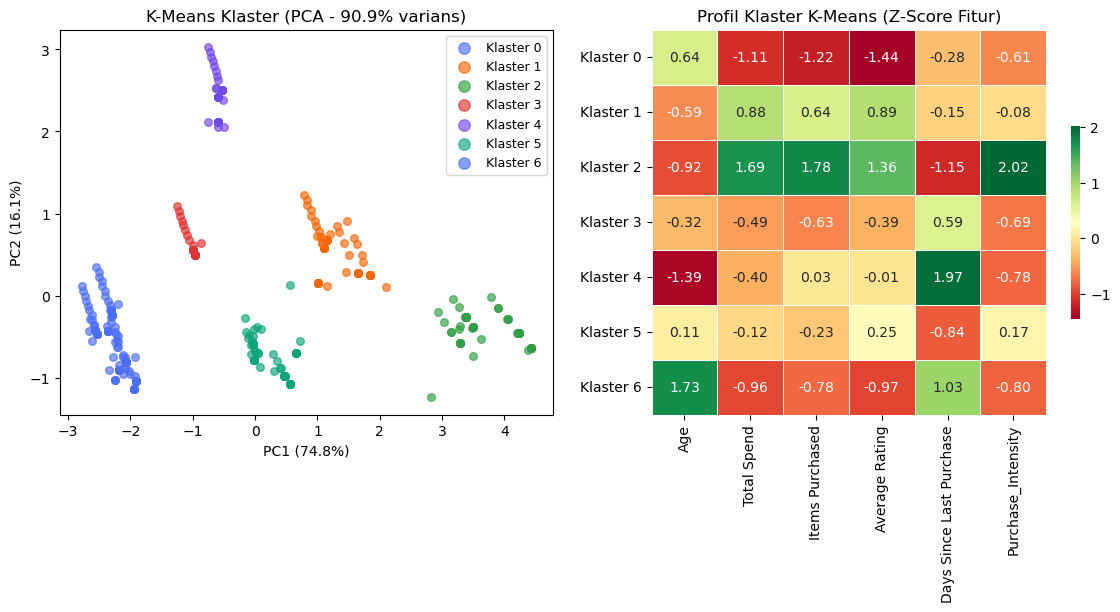

In [71]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_r = pca.explained_variance_ratio_

plt.figure(figsize=(14,5))
 

plt.subplot(1,2,1)
plt.title(f"K-Means Klaster (PCA - {sum(var_r)*100:.1f}% varians)")
for cl in sorted(df_clean["KMeans Cluster"].unique()):
    m = df_clean["KMeans Cluster"] == cl
    plt.scatter(X_pca[m, 0], X_pca[m, 1], label=f"Klaster {cl}",
                 alpha=0.65, s=30, color=PALETTE[cl % len(PALETTE)])
plt.xlabel(f"PC1 ({var_r[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_r[1]*100:.1f}%)")
plt.legend(markerscale=1.5, fontsize=9)

plt.subplot(1,2,2)
plt.title("Profil Klaster K-Means (Z-Score Fitur)")
centroid_z = pd.DataFrame(
    scaler.transform(km_profile),
    columns=features_ext,
    index=[f"Klaster {i}" for i in km_profile.index]
)
sns.heatmap(centroid_z, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, cbar_kws={"shrink": 0.5})
plt.xlabel("")
 

plt.show()

## DBScan

In [60]:
k_nn = 7 
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_scaled)
dist, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(dist[:, -1])

delta_kd = np.diff(k_dist)
threshold = np.percentile(delta_kd, 85)
cands = np.where(delta_kd > threshold)[0]
elbow_idx = cands[len(cands) // 2] if len(cands) > 0 else len(k_dist) // 2
eps_est = max(0.3, round(float(k_dist[elbow_idx]), 2))

print(f"estimasi eps dari k-distance graph: {eps_est}")

estimasi eps dari k-distance graph: 0.3


In [62]:
best_config, best_score = None, -np.inf
results_dbscan = []
eps_candidates = sorted(set([
    max(0.1, eps_est - 0.2), max(0.1, eps_est),
    eps_est + 0.2, eps_est + 0.5, eps_est + 1.0, eps_est + 1.5
]))
 
for eps in eps_candidates:
    for ms in [5, 7, 10]:
        db     = DBSCAN(eps=round(eps, 2), min_samples=ms).fit(X_scaled)
        labels = db.labels_
        n_noise  = int((labels == -1).sum())
        n_clust  = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = n_noise / len(labels) * 100
        valid_mask = labels != -1
        sil = (silhouette_score(X_scaled[valid_mask], labels[valid_mask])
               if n_clust >= 2 and valid_mask.sum() > 10 else -1)
        results_dbscan.append(dict(eps=round(eps, 2), min_samples=ms,
                                   n_clusters=n_clust, n_noise=n_noise,
                                   noise_pct=round(noise_pct, 1),
                                   silhouette=round(sil, 4)))
        if n_clust >= 2 and noise_pct < 40 and sil > best_score:
            best_score  = sil
            best_config = dict(eps=round(eps, 2), min_samples=ms)

if best_config is None:
    df_r = pd.DataFrame(results_dbscan)
    valid = df_r[df_r["n_clusters"] >= 1]
    row = (valid.loc[valid["n_noise"].idxmin()]
           if len(valid) else df_r.loc[df_r["n_noise"]].idxmin())
    best_config = dict(eps=float(row["eps"]), min_samples=int(row["min_samples"]))
        
print("\n [ Hasil Grid-Search DBScan ]")
print(pd.DataFrame(results_dbscan).to_string(index=False))
                


 [ Hasil Grid-Search DBScan ]
 eps  min_samples  n_clusters  n_noise  noise_pct  silhouette
 0.1            5          26      124       35.6      0.9216
 0.1            7          22      147       42.2      0.9397
 0.1           10           7      262       75.3      0.9538
 0.3            5          22       27        7.8      0.6529
 0.3            7          20       38       10.9      0.6708
 0.3           10          12      116       33.3      0.7667
 0.5            5          10        4        1.1      0.6888
 0.5            7          10        5        1.4      0.6931
 0.5           10           8       24        6.9      0.7170
 0.8            5           7        2        0.6      0.7102
 0.8            7           7        2        0.6      0.7102
 0.8           10           7        2        0.6      0.7102
 1.3            5           3        0        0.0      0.4663
 1.3            7           3        0        0.0      0.4663
 1.3           10           3        0 

In [64]:
db_final = DBSCAN(**best_config).fit(X_scaled)
df_clean["DBSCAN_Cluster"] = db_final.labels_
 
n_noise_f = int((db_final.labels_ == -1).sum())
n_clust_f = len(set(db_final.labels_)) - 1
 
print(f"\n✔ Konfigurasi Terpilih : eps={best_config['eps']}, "
      f"min_samples={best_config['min_samples']}")
print(f"  Jumlah Klaster DBSCAN  : {n_clust_f}")
print(f"  Pelanggan Noise        : {n_noise_f} dari {len(df_clean)} "
      f"({n_noise_f/len(df_clean)*100:.1f}%)")
print("\n[Distribusi Label DBSCAN]  (-1 = noise/outlier)")
print(df_clean["DBSCAN_Cluster"].value_counts().sort_index())


✔ Konfigurasi Terpilih : eps=0.1, min_samples=5
  Jumlah Klaster DBSCAN  : 26
  Pelanggan Noise        : 124 dari 348 (35.6%)

[Distribusi Label DBSCAN]  (-1 = noise/outlier)
DBSCAN_Cluster
-1     124
 0      12
 1       8
 2      15
 3      10
 4       8
 5      10
 6       5
 7       8
 8      16
 9      10
 10     15
 11      8
 12      7
 13      7
 14      7
 15      8
 16      8
 17      7
 18      9
 19      6
 20      5
 21      6
 22      7
 23      7
 24      7
 25      8
Name: count, dtype: int64


In [65]:
noise_df = df_clean[df_clean["DBSCAN_Cluster"] == -1]
if len(noise_df) > 0:
    print("\n[Profil Rata-Rata Pelanggan Noise vs Keseluruhan]")
    comp = pd.DataFrame({
        "Noise": noise_df[features].mean().round(2),
        "Semua": df_clean[features].mean().round(2)
    })
    print(comp)
 


[Profil Rata-Rata Pelanggan Noise vs Keseluruhan]
                           Noise   Semua
Age                        33.60   33.58
Total Spend               827.46  847.79
Items Purchased            12.38   12.63
Average Rating              3.99    4.02
Days Since Last Purchase   29.16   26.61


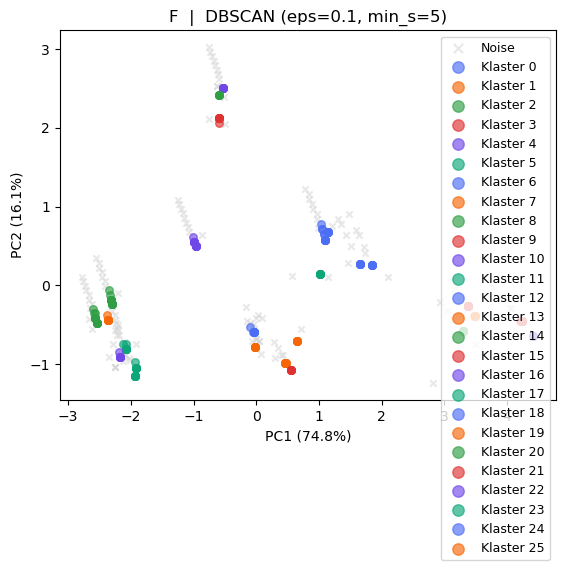

In [68]:
plt.title(f"F  |  DBSCAN (eps={best_config['eps']}, "
               f"min_s={best_config['min_samples']})")
for label in sorted(df_clean["DBSCAN_Cluster"].unique()):
    m = df_clean["DBSCAN_Cluster"] == label
    if label == -1:
        plt.scatter(X_pca[m, 0], X_pca[m, 1], label="Noise",
                     alpha=0.5, s=20, color="lightgray", marker="x")
    else:
        plt.scatter(X_pca[m, 0], X_pca[m, 1], label=f"Klaster {label}",
                     alpha=0.65, s=30, color=PALETTE[label % len(PALETTE)])
plt.xlabel(f"PC1 ({var_r[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_r[1]*100:.1f}%)")
plt.legend(markerscale=1.5, fontsize=9)
plt.show()

## Analisis Kritis

In [67]:
sil_km = silhouette_score(X_scaled, df_clean["KMeans Cluster"])
mask_v = df_clean["DBSCAN_Cluster"] != -1
sil_db = (silhouette_score(X_scaled[mask_v], df_clean.loc[mask_v, "DBSCAN_Cluster"])
          if mask_v.sum() > 10 and n_clust_f >= 2 else -1)
 
print(f"\nSilhouette Score K-Means (K={chosen_k}) : {sil_km:.4f}")
print(f"Silhouette Score DBSCAN              : {sil_db:.4f}")


Silhouette Score K-Means (K=7) : 0.7054
Silhouette Score DBSCAN              : 0.9216


## Kesimpulan – Mana yang Lebih Efektif untuk Target Promosi Diskon?

**K-Means lebih efektif untuk strategi promosi diskon**, dengan alasan:

### 1. Segmentasi Menyeluruh
Setiap pelanggan masuk ke tepat satu klaster.  
Tim marketing bisa langsung menetapkan aksi per klaster:

- **Klaster spending tinggi + baru beli** → loyalty reward  
- **Klaster spending rendah + lama beli** → diskon reaktivasi  
- **Klaster muda + impulsif** → flash sale / limited offer  

### 2. Profil yang Dapat Dieksekusi
Centroid tiap klaster merepresentasikan **persona rata-rata pelanggan**.  
Lebih mudah dipresentasikan ke tim non-teknis tanpa harus memahami konsep **density** atau **epsilon**.

### 3. Fleksibilitas Jumlah Segmen
Nilai **K** dapat disesuaikan dengan kapasitas tim marketing:

- **K = 3** → kampanye kecil  
- **K = 7** → kampanye besar  

---

### DBSCAN sebagai Pelengkap
DBSCAN tetap bernilai sebagai **pelengkap**:

Pelanggan noise (**124 dari 348 orang**) dapat menjadi kandidat anomali, misalnya:

- Pelanggan VIP dengan pola unik  
- Akun mencurigakan yang memerlukan investigasi manual  

---

## Ringkasan Akhir
  - Dataset               : 348 pelanggan, 11 fitur asli
  - Missing values        : 2 (Satisfaction Level) → diisi modus
  - Outlier Total Spend   : 0 (IQR) → semua Potential VIP, tidak ada data error
  - Fitur baru            : Purchase_Intensity
  - Standarisasi          : StandardScaler (μ=0, σ=1)
  - K-Means K             : 7  |  Silhouette = 0.7054
  - DBSCAN config         : eps=0.1, min_samples=5
  - DBSCAN klaster        : 26  |  Noise = 124 pelanggan (35.6%)
  - DBSCAN Silhouette     : 0.9216

- Rekomendasi: Gunakan K-Means (K=7) untuk target promosi diskon dan DBSCAN noise points untuk investigasi pelanggan anomali.


----
# Aria Aura Rachman | 101012400265